In [1]:
import pandas as pd
import numpy as np

## A. Data cleaning

In [2]:
df = pd.read_csv('HR_Dataset Refresh.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               582 non-null    str    
 1   EmpID                       582 non-null    int64  
 2   MarriedID                   582 non-null    int64  
 3   MaritalStatusID             582 non-null    int64  
 4   GenderID                    582 non-null    int64  
 5   EmpStatusID                 582 non-null    int64  
 6   DeptID                      582 non-null    int64  
 7   PerfScoreID                 582 non-null    int64  
 8   FromDiversityJobFairID      582 non-null    int64  
 9   Salary                      582 non-null    int64  
 10  Termd                       582 non-null    int64  
 11  PositionID                  582 non-null    int64  
 12  Position                    582 non-null    str    
 13  State                       582 non-null    st

In [3]:
df.isnull().sum()

Employee_Name                   0
EmpID                           0
MarriedID                       0
MaritalStatusID                 0
GenderID                        0
EmpStatusID                     0
DeptID                          0
PerfScoreID                     0
FromDiversityJobFairID          0
Salary                          0
Termd                           0
PositionID                      0
Position                        0
State                           0
Zip                             0
DOB                             0
Gender                          0
MaritalDesc                     0
CitizenDesc                     0
HispanicLatino                  0
RaceDesc                        0
DateofHire                      0
DateofTermination             386
TermReason                      0
EmploymentStatus                0
Department                      0
ManagerName                     0
ManagerID                       8
RecruitmentSource               0
PerformanceSco

In [4]:
mgr_mode = df['ManagerID'].mode()[0]
df['ManagerID'] = df['ManagerID'].fillna(mgr_mode)
df['ManagerID'].unique()
print(mgr_mode)

16.0


### Here a few employee records are missing their manager's ID number.
    So i replace missing values with the mode (the most frequent manager ID) rather than dropping the rows entirely.
    Deleting whole employee records reduces sample size and distorts turnover figures. Since manager IDs are whole numbers, using the mode keeps the data clean

In [5]:
df['ManagerID']=df['ManagerID'].astype(int)
df['ManagerID'].unique()

array([22,  4, 20, 16, 39, 11, 10, 19, 12,  7, 14, 18,  3,  2,  1, 17,  5,
       21,  6, 15, 13,  9, 30])

In [6]:
# convert to datatime
df['DOB'] = pd.to_datetime(df['DOB'], format='mixed', dayfirst=True)
df['DOB']

0     1983-10-07
1     1975-05-05
2     1988-09-19
3     1988-09-27
4     1989-08-09
         ...    
577   1989-08-09
578   1977-05-22
579   1979-05-24
580   1983-02-18
581   1970-11-02
Name: DOB, Length: 582, dtype: datetime64[us]

In [7]:
# create function to apply all date columns
def changeDateTime(dataframe, *args):
    for col in args:
        dataframe[col] = pd.to_datetime(dataframe[col],format='mixed')

In [8]:
changeDateTime(df, 'DOB', 'DateofHire', 'DateofTermination', 'LastPerformanceReview_Date')
df[['DOB', 'DateofHire', 'DateofTermination', 'LastPerformanceReview_Date']]

,DOB,DateofHire,DateofTermination,LastPerformanceReview_Date
0,1983-10-07,2011-07-05,NaT,2019-01-17
1,1975-05-05,2015-03-30,2016-06-16,2016-02-24
2,1988-09-19,2011-07-05,2012-09-24,2012-05-15
3,1988-09-27,2008-01-07,NaT,2019-01-03
4,1989-08-09,2011-07-11,2016-09-06,2016-02-01
...,...,...,...,...
577,1989-08-09,2011-07-11,2016-09-06,2016-02-01
578,1977-05-22,2012-01-09,NaT,2019-01-07
579,1979-05-24,2014-11-10,NaT,2019-01-02
580,1983-02-18,2013-09-30,NaT,2019-02-25


### Above dates like hire dates and termination dates were loaded as text strings.

So, i convert them into standard datetime formats using pd.to_datetime().

Computers can't subtract text to measure time. Standardizing dates allows us to calculate crucial HR metrics like employee age, total tenure (years at the company), and exact time before resignation.

### Removing whitespaces

In [9]:
#columns = df.select_dtypes(['object', 'float64']) # cant use float
columns = df.select_dtypes(['object'])
columns.columns 

C:\Users\User\AppData\Local\Temp\ipykernel_12860\1712739449.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columns = df.select_dtypes(['object'])


Index(['Employee_Name', 'Position', 'State', 'Gender', 'MaritalDesc',
       'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'TermReason',
       'EmploymentStatus', 'Department', 'ManagerName', 'RecruitmentSource',
       'PerformanceScore'],
      dtype='str')

In [10]:
columns = ['Employee_Name', 'Position', 'State', 'Gender', 'MaritalDesc',
       'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'TermReason',
       'EmploymentStatus', 'Department', 'ManagerName', 'RecruitmentSource',
       'PerformanceScore']

def checkUniqueValuesforList(dataframe, listColumns):
    for col in listColumns:
        unique_value = dataframe[col].unique()
        print(col)
        print('--------'*10)
        print(unique_value)
        

In [11]:
checkUniqueValuesforList(df, columns)

Employee_Name
--------------------------------------------------------------------------------
<ArrowStringArray>
[     'Adinolfi, Wilson  K', 'Ait Sidi, Karthikeyan   ',
        'Akinkuolie, Sarah',             'Alagbe,Trina',
         'Anderson, Carol ',        'Anderson, Linda  ',
          'Andreola, Colby',              'Athwal, Sam',
         'Bachiochi, Linda',       'Bacong, Alejandro ',
 ...
            'Wilber, Barry',            'Wilkes, Annie',
    'Williams, Jacquelyn  ',       'Winthrop, Jordan  ',
            'Wolk, Hang  T',           'Woodson, Jason',
       'Ybarra, Catherine ',         'Zamora, Jennifer',
              'Zhou, Julia',            'Zima, Colleen']
Length: 311, dtype: str
Position
--------------------------------------------------------------------------------
<ArrowStringArray>
[     'Production Technician I',                      'Sr. DBA',
     'Production Technician II',            'Software Engineer',
                   'IT Support',                

In [12]:
# way to remove
df['Department'] = df['Department'].str.strip()
# df['Department'].unique()

In [13]:
# to apply to all columns create function
def removeWhiteSpace(dataframe, listColumns):
    for col in listColumns:
        dataframe[col] = dataframe[col].str.strip()

In [14]:
removeWhiteSpace(df, columns)
print(columns)

['Employee_Name', 'Position', 'State', 'Gender', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'TermReason', 'EmploymentStatus', 'Department', 'ManagerName', 'RecruitmentSource', 'PerformanceScore']


In [15]:
# string function to make first letter capital and title format
df['HispanicLatino'].unique()

<ArrowStringArray>
['No', 'Yes', 'no', 'yes']
Length: 4, dtype: str

In [16]:
df['HispanicLatino'] = df['HispanicLatino'].str.title()

#or
h1_map = {
    'no':'NO',
    'yes':'Yes',
    'No':'No',
    'Yes':'Yes'
}
df['HispanicLatino']=df['HispanicLatino'].map(h1_map)

In [17]:
# replace, eg commas in full name
df['Employee_Name'] = df['Employee_Name'].str.replace(',' , ' ', regex=False)

In [18]:
df['EmpID'].nunique()
# print("Duplicates in ID:", df.duplicated(subset=['EmpID']).sum())

311

### Above inputs like 'yes', 'YES', 'No', and trailing whitespace lead to messy grouping.

I convert key category text to title case, strip extra spacing, and map mixed entries into unified terms.

Reason : Without this step, a chart would count 'Yes' and 'yes' as two completely different departments, giving us misleading stats.

In [19]:
## now duplicated
duplicate_data = df[df.duplicated()]
duplicate_data

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
19,Adinolfi Wilson K,10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22,LinkedIn,Exceeds,4.60,5,0,2019-01-17,0,1
20,Ait Sidi Karthikeyan,10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4,Indeed,Fully Meets,4.96,3,6,2016-02-24,0,17
21,Akinkuolie Sarah,10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20,LinkedIn,Fully Meets,3.02,3,0,2012-05-15,0,3
22,Alagbe Trina,10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16,Indeed,Fully Meets,4.84,5,0,2019-01-03,0,15
23,Anderson Carol,10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39,Google Search,Fully Meets,5.00,4,0,2016-02-01,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,Anderson Carol,10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39,Google Search,Fully Meets,5.00,4,0,2016-02-01,0,2
578,Anderson Linda,10002,0,0,0,1,5,4,0,57568,...,Amy Dunn,11,LinkedIn,Exceeds,5.00,5,0,2019-01-07,0,15
579,Andreola Colby,10194,0,0,0,1,4,3,0,95660,...,Alex Sweetwater,10,LinkedIn,Fully Meets,3.04,3,4,2019-01-02,0,19
580,Athwal Sam,10062,0,4,1,1,5,3,0,59365,...,Ketsia Liebig,19,Employee Referral,Fully Meets,5.00,4,0,2019-02-25,0,19


In [20]:
df=df.drop_duplicates(subset='Employee_Name', keep='first')
df

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,Adinolfi Wilson K,10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22,LinkedIn,Exceeds,4.60,5,0,2019-01-17,0,1
1,Ait Sidi Karthikeyan,10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4,Indeed,Fully Meets,4.96,3,6,2016-02-24,0,17
2,Akinkuolie Sarah,10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20,LinkedIn,Fully Meets,3.02,3,0,2012-05-15,0,3
3,Alagbe Trina,10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16,Indeed,Fully Meets,4.84,5,0,2019-01-03,0,15
4,Anderson Carol,10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39,Google Search,Fully Meets,5.00,4,0,2016-02-01,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,Woodson Jason,10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20,LinkedIn,Fully Meets,4.07,4,0,2019-02-28,0,13
326,Ybarra Catherine,10301,0,0,0,5,5,1,0,48513,...,Brannon Miller,12,Google Search,PIP,3.20,2,0,2015-09-02,5,4
327,Zamora Jennifer,10010,0,0,0,1,3,4,0,220450,...,Janet King,2,Employee Referral,Exceeds,4.60,5,6,2019-02-21,0,16
328,Zhou Julia,10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4,Employee Referral,Fully Meets,5.00,3,5,2019-02-01,0,11


In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 311 entries, 0 to 329
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Employee_Name               311 non-null    str           
 1   EmpID                       311 non-null    int64         
 2   MarriedID                   311 non-null    int64         
 3   MaritalStatusID             311 non-null    int64         
 4   GenderID                    311 non-null    int64         
 5   EmpStatusID                 311 non-null    int64         
 6   DeptID                      311 non-null    int64         
 7   PerfScoreID                 311 non-null    int64         
 8   FromDiversityJobFairID      311 non-null    int64         
 9   Salary                      311 non-null    int64         
 10  Termd                       311 non-null    int64         
 11  PositionID                  311 non-null    int64         
 12  Position  

In [22]:
df.describe()

,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,...,DOB,DateofHire,DateofTermination,ManagerID,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
count,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,...,311,311,104,311.000000,311.000000,311.000000,311.000000,311,311.000000,311.000000
mean,10156.000000,0.398714,0.810289,0.434084,2.392283,4.610932,2.977492,0.093248,69020.684887,0.334405,...,1979-02-06 22:08:52.475884,2013-02-03 22:50:32.797427,2015-06-14 11:46:09.230769,14.607717,4.110000,3.890675,1.218650,2017-09-10 21:17:56.527331,0.414791,10.237942
min,10001.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,45046.000000,0.000000,...,1951-02-01 00:00:00,2006-01-09 00:00:00,2010-08-30 00:00:00,1.000000,1.120000,1.000000,0.000000,2010-07-14 00:00:00,0.000000,1.000000
25%,10078.500000,0.000000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000,55501.500000,0.000000,...,1973-12-02 00:00:00,2011-07-11 00:00:00,2014-01-10 12:00:00,10.000000,3.690000,3.000000,0.000000,2016-03-19 12:00:00,0.000000,5.000000
50%,10156.000000,0.000000,1.000000,0.000000,1.000000,5.000000,3.000000,0.000000,62810.000000,0.000000,...,1980-12-05 00:00:00,2013-02-18 00:00:00,2015-09-22 00:00:00,16.000000,4.280000,4.000000,0.000000,2019-01-16 00:00:00,0.000000,10.000000
75%,10233.500000,1.000000,1.000000,1.000000,5.000000,5.000000,3.000000,0.000000,72036.000000,1.000000,...,1986-04-24 12:00:00,2014-09-23 12:00:00,2016-09-08 06:00:00,19.000000,4.700000,5.000000,0.000000,2019-02-04 00:00:00,0.000000,15.000000
max,10311.000000,1.000000,4.000000,1.000000,5.000000,6.000000,4.000000,1.000000,250000.000000,1.000000,...,1992-08-17 00:00:00,2018-07-09 00:00:00,2018-11-10 00:00:00,39.000000,5.000000,5.000000,8.000000,2019-02-28 00:00:00,6.000000,20.000000
std,89.922189,0.490423,0.943239,0.496435,1.794383,1.083487,0.587072,0.291248,25156.636930,0.472542,...,NaN,NaN,NaN,7.976607,0.789938,0.909241,2.349421,NaN,1.294519,5.852596


## B. Conditional filtering

In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 311 entries, 0 to 329
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Employee_Name               311 non-null    str           
 1   EmpID                       311 non-null    int64         
 2   MarriedID                   311 non-null    int64         
 3   MaritalStatusID             311 non-null    int64         
 4   GenderID                    311 non-null    int64         
 5   EmpStatusID                 311 non-null    int64         
 6   DeptID                      311 non-null    int64         
 7   PerfScoreID                 311 non-null    int64         
 8   FromDiversityJobFairID      311 non-null    int64         
 9   Salary                      311 non-null    int64         
 10  Termd                       311 non-null    int64         
 11  PositionID                  311 non-null    int64         
 12  Position  

### Exercise 1: Finding High Performers with High Salary
Goal: Filter for employees who have an EmpSatisfaction score of 5 (or a top PerformanceScore) and earn more than $80,000.

In [24]:
high_performers = df[(df['Salary']>80000) & (df['PerformanceScore']=='Exceeds')]
high_performers[['Employee_Name', 'Position', 'Salary', 'EmpSatisfaction']]

,Employee_Name,Position,Salary,EmpSatisfaction
12,Barbossa Hector,Data Analyst,92328,4
74,Corleone Vito,Director of Operations,170500,5
95,Dougall Eric,IT Manager - Support,138888,5
115,Foss Jason,IT Director,178000,5
231,Patronick Lucas,Software Engineer,108987,5
239,Petrowsky Thelma,Data Analyst,93554,5
293,Szabo Andrew,Software Engineer,92989,5
327,Zamora Jennifer,CIO,220450,5


### Exercise 2: Absenteeism & Punctuality Risk
Goal: Identify active employees who have been late more than 2 times in the last 30 days (DaysLateLast30 > 2) or have more than 15 total Absences. 

In [25]:
punctual_test = df[(df['DaysLateLast30']>2) | (df['Absences']>15)]
punctual_test[['Employee_Name', 'Absences', 'DaysLateLast30']]

,Employee_Name,Absences,DaysLateLast30
1,Ait Sidi Karthikeyan,17,0
6,Andreola Colby,19,0
7,Athwal Sam,19,0
9,Bacong Alejandro,16,0
15,Bates Norman,20,0
...,...,...,...
316,Wallace Theresa,13,6
317,Wang Charlie,17,0
322,Williams Jacquelyn,16,0
326,Ybarra Catherine,4,5


### Exercise 3: Recruitment Source & Department Analysis
Goal: Find all active employees in the Software Engineering or IT/IS departments who were recruited via LinkedIn.

In [26]:
df['RecruitmentSource'].unique()

<ArrowStringArray>
[               'LinkedIn',                  'Indeed',
           'Google Search',       'Employee Referral',
      'Diversity Job Fair', 'On-line Web application',
           'CareerBuilder',                 'Website',
                   'Other']
Length: 9, dtype: str

In [27]:
target_depts = ['Software Engineering', 'IT/IS']
via_linkedin = df[(df['Department'].isin(target_depts)) & (df['RecruitmentSource']=='LinkedIn')]
via_linkedin[['Employee_Name', 'Department', 'RecruitmentSource', 'Salary']]

,Employee_Name,Department,RecruitmentSource,Salary
6,Andreola Colby,Software Engineering,LinkedIn,95660
44,Booth Frank,IT/IS,LinkedIn,103613
58,Carr Claudia N,IT/IS,LinkedIn,100031
80,Daniele Ann,IT/IS,LinkedIn,85028
110,Fett Boba,IT/IS,LinkedIn,53366
118,Galia Lisa,IT/IS,LinkedIn,65707
128,Goeth Amon,IT/IS,LinkedIn,74679
258,Roehrich Bianca,IT/IS,LinkedIn,120000
268,Salter Jason,IT/IS,LinkedIn,88527
271,Shepard Anita,IT/IS,LinkedIn,50750


### Exercise 4: Terminated Employees & Exit Reasons
Goal: Filter for employees who have been terminated (Termd == 1) and whose termination reason is not 'Another position' (excluding standard voluntary resignations to see underlying retention issues).

In [28]:
terminated = df[(df['Termd']==1) & (df['TermReason']!='Another position')]
terminated[['Employee_Name', 'Department', 'TermReason', 'DateofTermination']]

,Employee_Name,Department,TermReason,DateofTermination
1,Ait Sidi Karthikeyan,IT/IS,career change,2016-06-16
2,Akinkuolie Sarah,Production,hours,2012-09-24
4,Anderson Carol,Production,return to school,2016-09-06
11,Barbara Thomas,Production,unhappy,2016-09-19
15,Bates Norman,Production,attendance,2017-08-04
...,...,...,...,...
316,Wallace Theresa,Production,career change,2015-09-01
319,Whittier Scott,Production,hours,2014-05-15
320,Wilber Barry,Production,unhappy,2015-09-07
322,Williams Jacquelyn,Production,relocation out of area,2015-06-27


### Exercise 5: Tenured & Active Project Leaders (Date Filtering)
Goal: Filter for currently active employees who were hired before 2015 (DateofHire < '2015-01-01') and have worked on at least one special project (SpecialProjectsCount > 0).

In [29]:
current_emp = df[(df['Termd']==0) & 
    (df['DateofHire']<'2015-01-01') & 
    (df['SpecialProjectsCount']>0)]
current_emp[['Employee_Name', 'Position', 'DateofHire', 'SpecialProjectsCount']]

,Employee_Name,Position,DateofHire,SpecialProjectsCount
6,Andreola Colby,Software Engineer,2014-11-10,4
12,Barbossa Hector,Data Analyst,2014-11-10,5
48,Brown Mia,Accountant I,2008-10-27,6
54,Cady Max,Software Engineering Manager,2011-08-15,5
56,Carabbio Judith,Software Engineer,2013-11-11,6
67,Clayton Rick,IT Support,2012-09-05,6
78,Cross Noah,Sr. Network Engineer,2014-11-10,4
80,Daniele Ann,Sr. Network Engineer,2014-11-10,8
85,Del Bosque Keyla,Software Engineer,2012-01-09,5
95,Dougall Eric,IT Manager - Support,2014-01-05,5


### C. Feature engineering for data analysis

In [30]:
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,Adinolfi Wilson K,10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22,LinkedIn,Exceeds,4.60,5,0,2019-01-17,0,1
1,Ait Sidi Karthikeyan,10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4,Indeed,Fully Meets,4.96,3,6,2016-02-24,0,17
2,Akinkuolie Sarah,10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20,LinkedIn,Fully Meets,3.02,3,0,2012-05-15,0,3
3,Alagbe Trina,10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16,Indeed,Fully Meets,4.84,5,0,2019-01-03,0,15
4,Anderson Carol,10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39,Google Search,Fully Meets,5.00,4,0,2016-02-01,0,2


In [31]:
df=df.copy()

In [32]:
df

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,Adinolfi Wilson K,10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22,LinkedIn,Exceeds,4.60,5,0,2019-01-17,0,1
1,Ait Sidi Karthikeyan,10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4,Indeed,Fully Meets,4.96,3,6,2016-02-24,0,17
2,Akinkuolie Sarah,10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20,LinkedIn,Fully Meets,3.02,3,0,2012-05-15,0,3
3,Alagbe Trina,10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16,Indeed,Fully Meets,4.84,5,0,2019-01-03,0,15
4,Anderson Carol,10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39,Google Search,Fully Meets,5.00,4,0,2016-02-01,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,Woodson Jason,10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20,LinkedIn,Fully Meets,4.07,4,0,2019-02-28,0,13
326,Ybarra Catherine,10301,0,0,0,5,5,1,0,48513,...,Brannon Miller,12,Google Search,PIP,3.20,2,0,2015-09-02,5,4
327,Zamora Jennifer,10010,0,0,0,1,3,4,0,220450,...,Janet King,2,Employee Referral,Exceeds,4.60,5,6,2019-02-21,0,16
328,Zhou Julia,10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4,Employee Referral,Fully Meets,5.00,3,5,2019-02-01,0,11


In [33]:
df['Year'] = df['DateofHire'].dt.year
df['Month'] = df['DateofHire'].dt.month
df['Day'] = df['DateofHire'].dt.day

In [34]:
df['Hire_month_name'] = df['DateofHire'].dt.month_name()
df['Hire_day_name'] = df['DateofHire'].dt.day_name()
df['Hire_month_name'].unique()

<ArrowStringArray>
[     'July',     'March',   'January',  'November', 'September',     'April',
  'February',    'August',   'October',      'June',       'May',  'December']
Length: 12, dtype: str

### convert continuous data to categorical data

In [35]:
# change salary to levels and then to numbers using map
def changeSalary(salary):
    if salary >= 0 and salary < 40000:
        return 'Low Salary'
    elif salary >=40000 and salary < 100000:
        return 'Medium Salary'
    elif salary > 100000:
        return 'High Salary'
    else:
        return 'Invalid Salary'    

In [36]:
df['Salary_label'] = df['Salary'].apply(changeSalary)
df['Salary_label'].unique()

<ArrowStringArray>
['Medium Salary', 'High Salary']
Length: 2, dtype: str

##
Since you have 4 datetime64 columns (DOB, DateofHire, DateofTermination, LastPerformanceReview_Date), you can engineer some of the most powerful features in HR analytics:

In [37]:
# 1.employee age
df['Age'] = (pd.Timestamp.now() - df['DOB']).dt.days//365
df['Age'].unique()

array([42, 51, 37, 49, 47, 43, 55, 38, 52, 44, 60, 40, 67, 35, 59, 62, 39,
       36, 56, 46, 63, 75, 54, 41, 45, 50, 61, 74, 48, 71, 58, 34, 57, 53,
       73, 65, 70, 68])

In [38]:
# 2. Tenure(years at company)
df['Tenure_years'] = (pd.Timestamp.now() - df['DateofHire']).dt.days // 365
df['Tenure_years'].unique()

array([15, 11, 18, 14, 12, 17, 13, 10,  9, 16,  8, 19, 20])

In [39]:
# 3.Days Since Last Review:
df['Days_since_review'] = (pd.Timestamp.now() - df['LastPerformanceReview_Date']).dt.days
df['Days_since_review'].unique()

array([2781, 3839, 5219, 2795, 3862, 2791, 2796, 2742, 2773, 2749, 3864,
       3767, 2753, 3467, 3433, 2784, 4244, 2787, 2788, 2740, 4561, 3884,
       4573, 4926, 2783, 2766, 2777, 4948, 2746, 2745, 2768, 2755, 2748,
       2779, 4190, 5231, 5596, 2739, 3772, 2763, 2776, 2770, 2774, 2767,
       3801, 4133, 2775, 2769, 2780, 2794, 2771, 3429, 2754, 3061, 3513,
       5132, 3859, 4894, 5348, 2759, 2741, 2782, 3774, 4609, 4239, 2760,
       5655, 2752, 4835, 4957, 2790, 4137, 2756, 4959, 5290, 4154, 5252,
       3118, 3860, 4900, 4199, 2761, 4213, 4938, 3345, 3102, 3732, 4226,
       3437, 5171, 3858, 4975, 4928, 3828, 3095, 4806, 4031, 3878, 3432,
       4222, 4491, 4979, 4195, 5304, 3071, 4897, 4515, 3128, 4170, 5425,
       5349, 4249, 3798, 3119, 2980, 4255, 3127, 4149, 4167, 4762, 4198,
       5309, 3420, 3832, 5890, 3485, 4619, 3482, 4227, 5353, 4376, 2762,
       4489, 5683, 4471, 3875, 4014])

###
split first, middle and last name seperate

In [40]:
# --------------------

In [41]:
df.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Gender', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences', 'Year', 'Month', 'Day', 'Hire_month_name', 'Hire_day_name',
       'Salary_label', 'Age', 'Tenure_years', 'Days_since_review'],
      dtype='str')

## D. Data Analysis and Visualization

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

### 1. Salary & Compensation Analysis

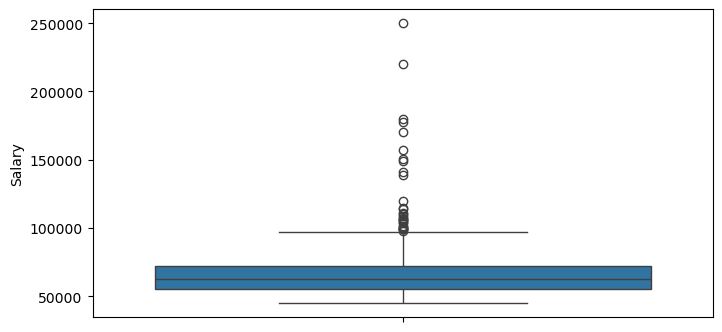

In [43]:
# Salary Distribution (Histogram / Boxplot):
# Goal: Check for skewness and identify outliers in income.
plt.figure(figsize=(8,4))
sns.boxplot(df['Salary'])
plt.show()

In [44]:
# Salary by Department & Position (Bar Plot):
# Goal: See which departments or roles command the highest and lowest average salaries.
department_salary = df.groupby('Department')['Salary'].sum()

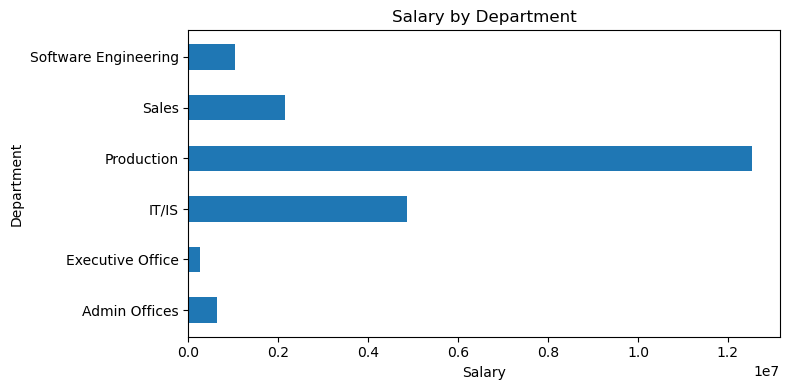

In [45]:
# total salary by department
fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(
    department_salary.index,
    department_salary.values,
    height=0.5 
)

ax.set_xlabel('Salary')
ax.set_ylabel('Department')   
ax.set_title('Salary by Department')

plt.tight_layout()
plt.show()

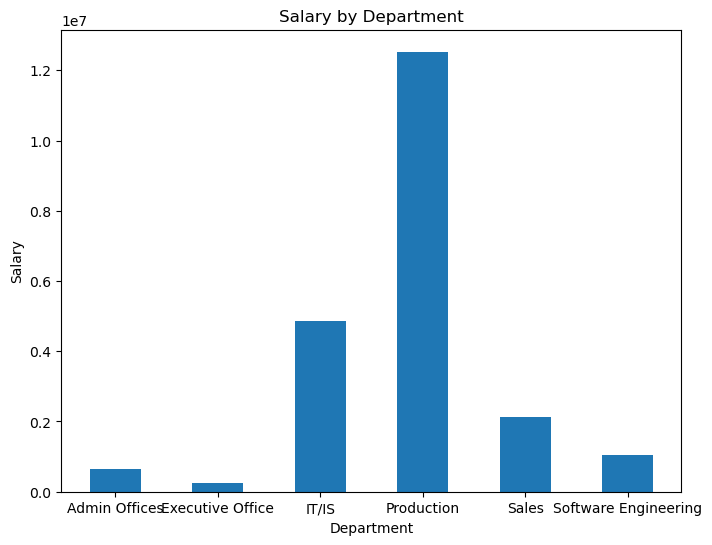

In [46]:
# total salary by department
fig, ax = plt.subplots(figsize=(8,6))
ax.bar(department_salary.index,
       department_salary.values,
       width = 0.5)
ax.set_xlabel('Department')
ax.set_ylabel('Salary')
ax.set_title('Salary by Department')
plt.show()

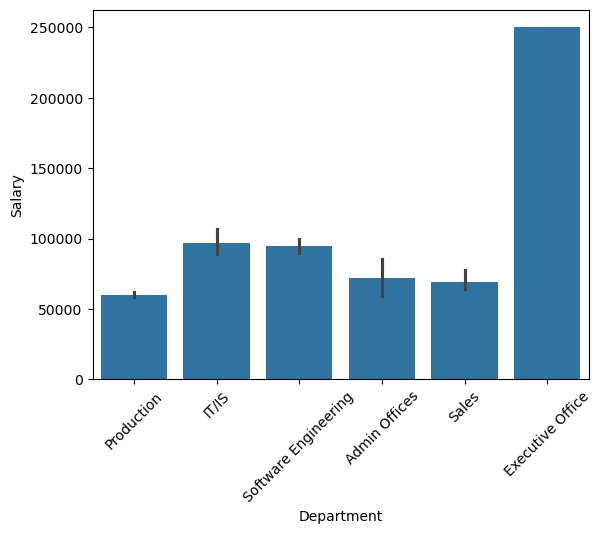

In [47]:
# mean salary of each department
ax = sns.barplot(x='Department', y='Salary', data=df, estimator=np.mean)
ax.tick_params(axis='x', rotation=45)

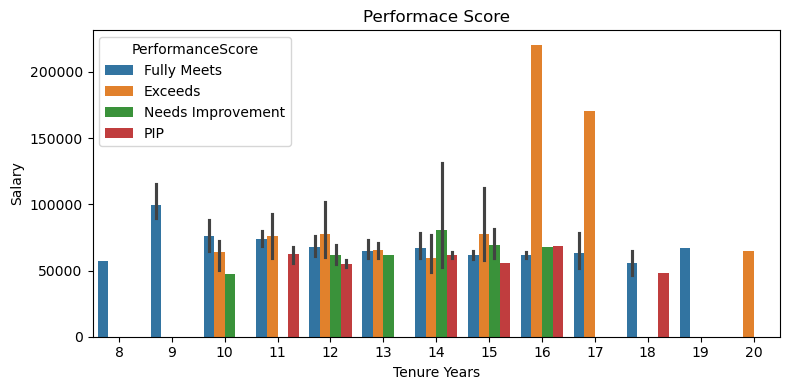

In [48]:
## Salary vs. Performance / Experience (Scatter Plot):
# Goal: Check if higher performance scores or higher tenure translate to higher pay.
fig, ax=plt.subplots(figsize=(8,4))
sns.barplot(
    data = df,
    x='Tenure_years',
    y = 'Salary',
    hue = 'PerformanceScore',
    ax=ax
)
ax.set_xlabel('Tenure Years')
ax.set_ylabel('Salary')
ax.set_title('Performace Score')
plt.tight_layout()
plt.show()


### 2. Retention & Turnover (Attrition) Analysis

In [49]:
# Overall Attrition Rate (Pie Chart / Donut Chart):
# Goal: What percentage of the total workforce has left?

termd_counts = df['Termd'].value_counts()
termd_counts

Termd
0    207
1    104
Name: count, dtype: int64

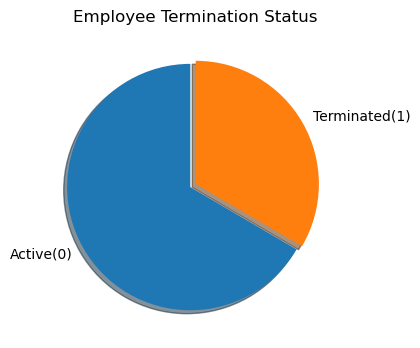

In [50]:
fig, ax=plt.subplots(figsize=(6,4))
explode = (0.05, 0)
ax.pie(
    termd_counts,
    labels = ['Active(0)', 'Terminated(1)'],
     startangle=90,                            # Rotates starting point to top
    explode=explode,
    shadow=True
)
ax.set_title('Employee Termination Status')

plt.show()
    

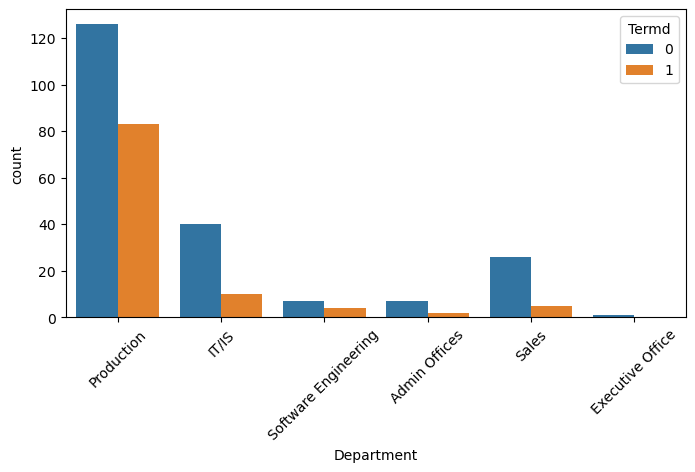

In [51]:
# Attrition by Department & Recruitment Source (Grouped Bar Chart):
#Goal: Which departments have the highest turnover? Which hiring channels yield the most long-term employees?
fig, ax=plt.subplots(figsize=(8,4))
sns.countplot(
    data = df,
    x = df['Department'],
    hue = 'Termd'
)
ax.tick_params(axis='x', rotation=45)
# plt.tight_layout()
plt.show()


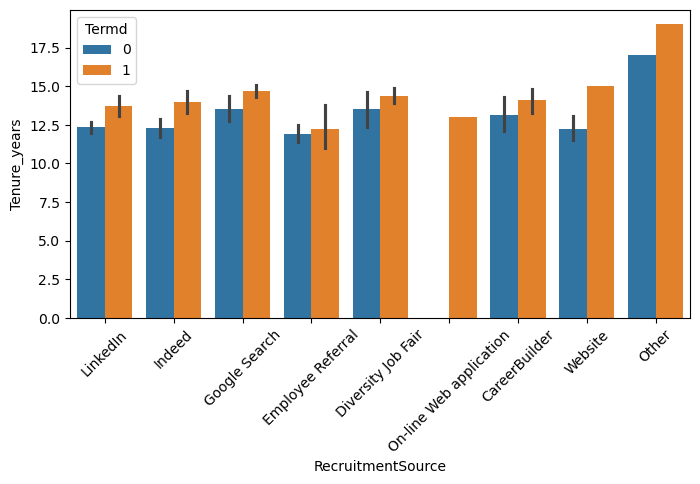

In [52]:
# Which hiring channels yield the most long-term employees?
fig, ax=plt.subplots(figsize=(8,4))
sns.barplot(
    data=df,
    x='RecruitmentSource',
    y='Tenure_years',
    hue = 'Termd',
    estimator=np.mean)
ax.tick_params(axis = 'x', rotation=45)
plt.show()

In [53]:
# Top Reasons for Termination (Horizontal Bar Chart):
# Goal: Identify the main root causes of employee departure.
active_df = df[df['Termd'] == 1]
term_cause = active_df.groupby('TermReason')['Termd'].count()
print(term_cause)

TermReason
Another position                    20
Fatal attraction                     1
Learned that he is a gangster        1
attendance                           7
career change                        9
gross misconduct                     1
hours                                8
maternity leave - did not return     3
medical issues                       3
military                             4
more money                          11
no-call, no-show                     4
performance                          4
relocation out of area               5
retiring                             4
return to school                     5
unhappy                             14
Name: Termd, dtype: int64


Text(0, 0.5, 'Termination cause')

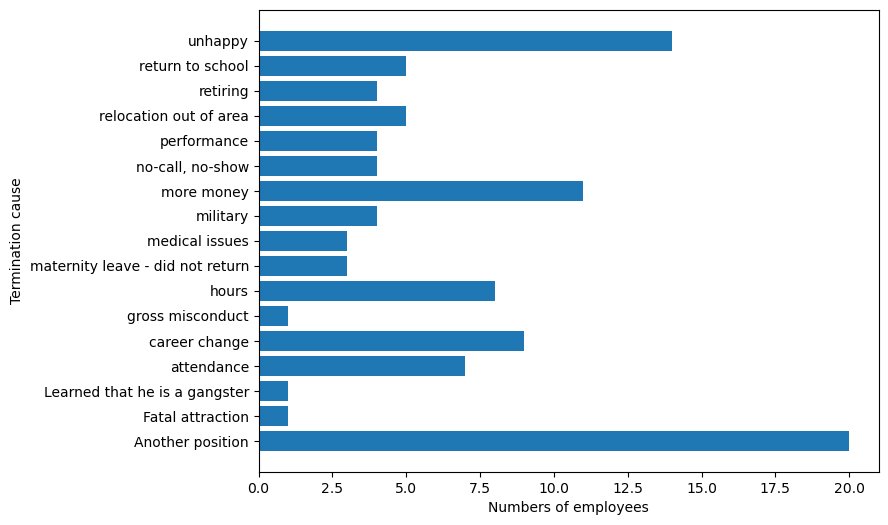

In [54]:
fig, ax=plt.subplots(figsize=(8,6))
ax.barh(term_cause.index,
       term_cause.values)
ax.set_xlabel('Numbers of employees')
ax.set_ylabel('Termination cause')

### 3. Employee Engagement, Satisfaction & Performance

Text(0.5, 1.0, 'Satisfaction vs. DaysLateLast30')

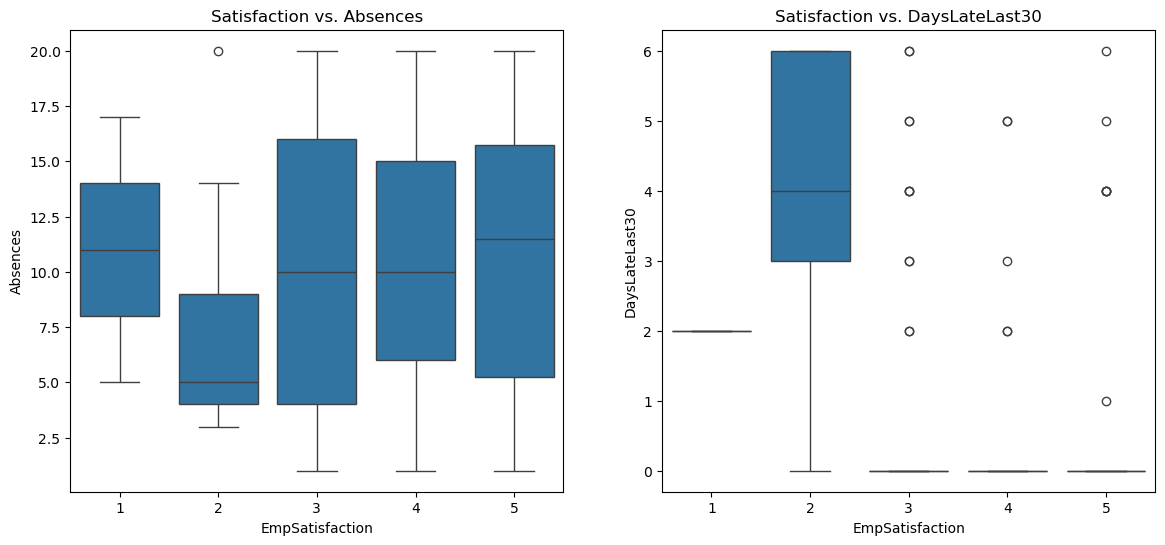

In [55]:
# Satisfaction vs. Absence / Lateness (Boxplot / Violin Plot):
# Goal: Do dissatisfied employees tend to have more absences (Absences) or late days (DaysLateLast30)?
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=df, x='EmpSatisfaction', y='Absences', ax=ax1)
ax1.set_title('Satisfaction vs. Absences')
#(Employee satisfaction does not appear to strongly drive or predict overall absences in this dataset.0

sns.boxplot(data=df, x='EmpSatisfaction', y='DaysLateLast30', ax=ax2)
ax2.set_title('Satisfaction vs. DaysLateLast30')
# (Dissatisfied employees (specifically level 2) are substantially more prone to being late
# frequently in the last 30 days compared to satisfied employees.)

In [56]:
emp_count = df['Employee_Name'].count()

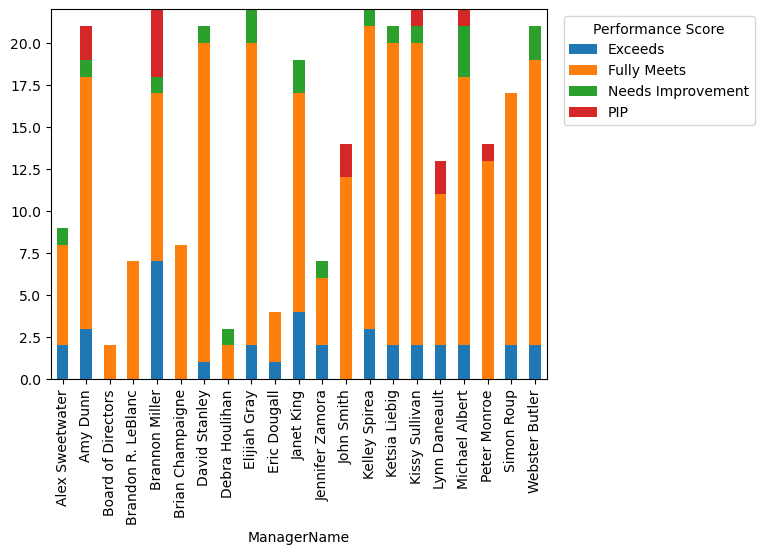

In [57]:
# Performance Breakdown by Manager (Stacked Bar Chart):
# Goal: Are certain managers consistently producing high performers, or high turnover?
# Pass normalize='index' to calculate proportions per manager, then multiply by 100

pd.crosstab(df['ManagerName'], df['PerformanceScore']).plot(kind='bar', stacked=True)
plt.legend(title='Performance Score', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

## 4. Diversity & Demographic Insights

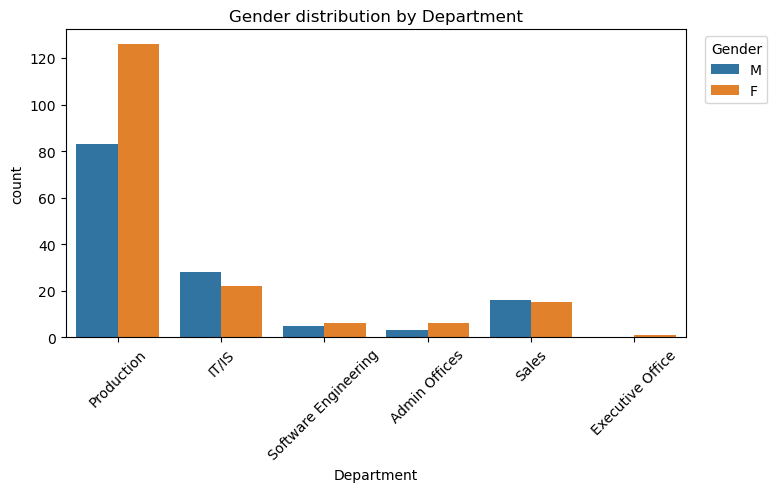

In [58]:
# Gender & Race Representation Across Departments (Count Plot):
# Goal: Analyze workplace diversity and inclusion across various teams.
fig, ax=plt.subplots(figsize=(8,4))
sns.countplot(
    data = df,
    x = 'Department',
    hue = 'Gender'
#    hue = 'RaceDesc'
)
ax.set_title('Gender distribution by Department')
plt.legend(title='Gender', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)

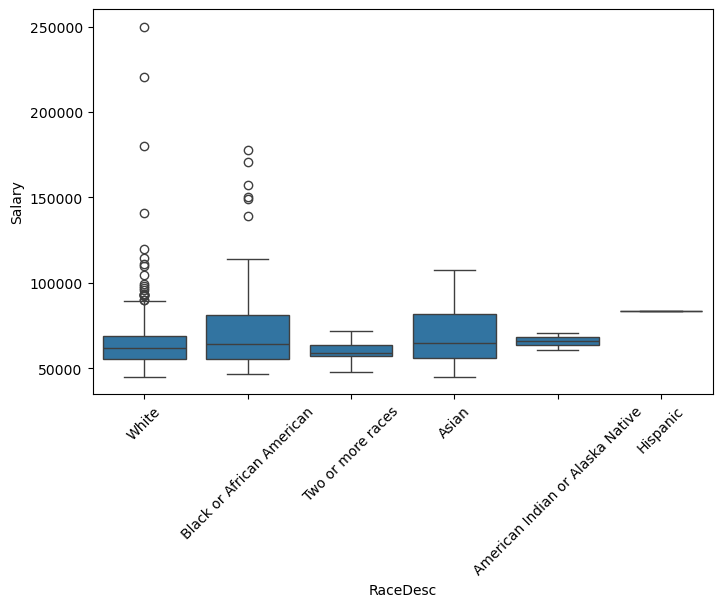

In [59]:
#Pay Gap Analysis (Boxplot):
#Goal: Compare salary distributions across gender or racial groups to check for equity.
fig, ax=plt.subplots(figsize=(8,5))
sns.boxplot(
    data=df,
    x ='RaceDesc',
#    x='Gender',
    y ='Salary'
)
ax.tick_params(axis='x', rotation=45)
# plt.tight_layout()
plt.show()

## 5. Correlation Heatmap (Numerical Features)

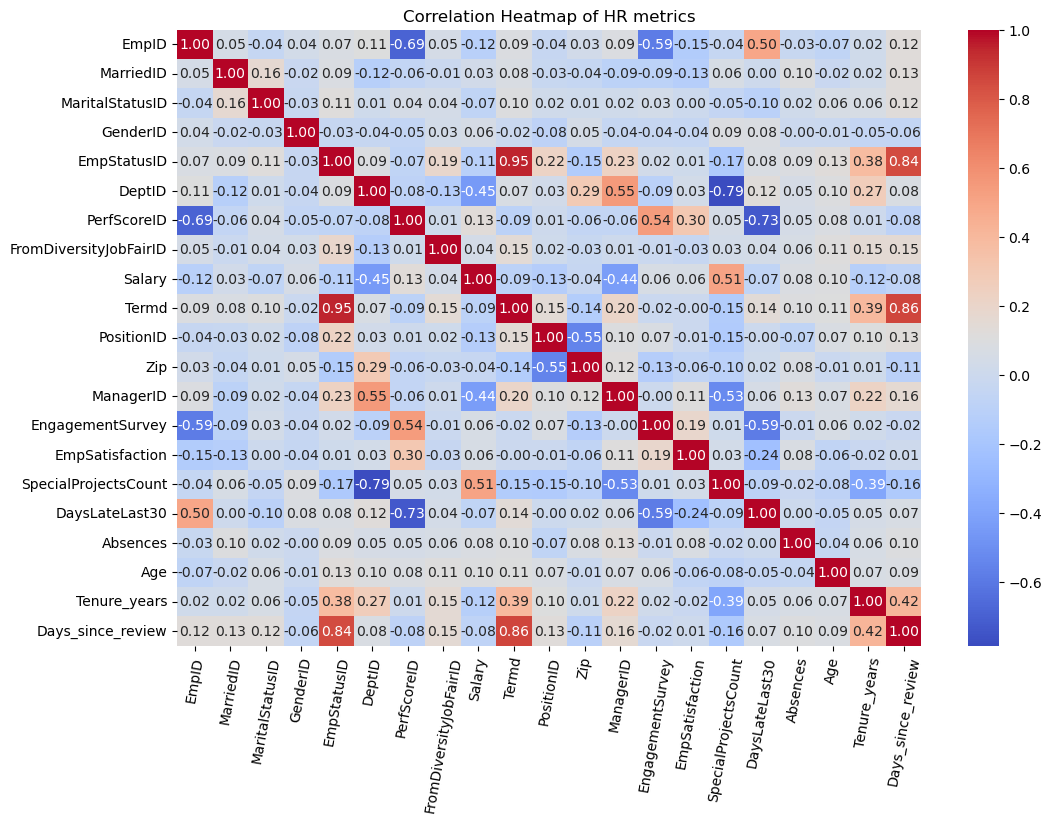

In [60]:
cor_data = df.select_dtypes(['int64', 'float64']).corr()
fig, ax=plt.subplots(figsize=(12,8))
sns.heatmap(cor_data, 
            cmap = 'coolwarm',
            fmt = '.2f',
            annot=True)
ax.set_title('Correlation Heatmap of HR metrics')
ax.tick_params(axis='x', rotation=80)

## E. Hypothesis Testing

### 1. One sample t_test
Scenario: Industry benchmark reports suggest that the average annual salary for HR and corporate roles in similar mid-sized companies is $68,000. You want to test if your company's average overall salary differs significantly from this standard.

In [61]:
from scipy import stats

In [62]:
alpha = 0.05
sample = 68000
population_mean = df['Salary']

In [63]:
stats.ttest_1samp(population_mean, popmean=sample)

TtestResult(statistic=np.float64(0.715515913457393), pvalue=np.float64(0.47482887489473813), df=np.int64(310))

In [64]:
t_statistics, p_value = stats.ttest_1samp(population_mean, popmean=sample)
print(t_statistics)
print(p_value)

0.715515913457393
0.47482887489473813


In [65]:
ho = f'The average ovarall salary in company is equal to 68000.'
ha = f'The average overall salary in company is not equal to 68000.'

In [66]:
print(f'ho: {ho}')
print(f'ha: {ha}')

ho: The average ovarall salary in company is equal to 68000.
ha: The average overall salary in company is not equal to 68000.


In [67]:
if p_value<alpha:
    print(f'Decision: Failed to accept null hypothesis at the alpha = 0.05 significance level. Required to accept alternative hypothisis. \nConclusion: {ha}')
else:
    print(f'Decision: Failed to reject null hypothesis at the alpha = 0.05 significance level. Required to accept null hypothesis. \nConclusion: {ho}')

Decision: Failed to reject null hypothesis at the alpha = 0.05 significance level. Required to accept null hypothesis. 
Conclusion: The average ovarall salary in company is equal to 68000.


### 2. Two sample t_test(independent)
Scenario: The management team wants to know if there is a statistically significant difference in the mean salary between Male and Female employees to evaluate compensation equity.

In [68]:
mean_salary=df.groupby('Gender')['Salary'].mean()
mean_salary
# wont work as it will create one-one sample

Gender
F    67786.727273
M    70629.400000
Name: Salary, dtype: float64

In [69]:
'''
alpha = 0.05
male_avg_salary =mean_salary['M']
female_avg_salary = mean_salary['F']
print(f'Average salary of male: {male_avg_salary}')
print(f'Average salary of female: {female_avg_salary}')
'''

"\nalpha = 0.05\nmale_avg_salary =mean_salary['M']\nfemale_avg_salary = mean_salary['F']\nprint(f'Average salary of male: {male_avg_salary}')\nprint(f'Average salary of female: {female_avg_salary}')\n"

In [70]:
male_salaries = df[df['Gender'] == 'M']['Salary']
female_salaries = df[df['Gender'] == 'F']['Salary']
print(male_salaries)
print(female_salaries)

0       62506
1      104437
7       59365
9       50178
11      47211
        ...  
317     84903
319     58371
320     55140
323     70507
325     65893
Name: Salary, Length: 135, dtype: int64
2       64955
3       64991
4       50825
5       57568
6       95660
        ...  
324     60446
326     48513
327    220450
328     89292
329     45046
Name: Salary, Length: 176, dtype: int64


In [71]:
alpha = 0.05
t_statistics, p_value = stats.ttest_ind(male_salaries, female_salaries, equal_var = False)
print(f' t_statistics: {t_statistics}')
print(f' p_value: {p_value}')

 t_statistics: 0.9955973253605694
 p_value: 0.32025794255222106


In [72]:
ho = f'The average salary of male and female are equal.'
ha = f'The average salary of male and female are not equal.'


In [73]:
print(f'Ho: {ho}')
print(f'Ha: {ha}')
print(f'Average male salary: ${male_salaries.mean():,.2f}')
print(f'Average female salary: ${female_salaries.mean():,.2f}')

Ho: The average salary of male and female are equal.
Ha: The average salary of male and female are not equal.
Average male salary: $70,629.40
Average female salary: $67,786.73


In [74]:
if p_value<alpha:
    print(f'Decision: Failed to accept null hypothesis. Required to accept alternative hypothesis. \nConclusion: {ha}')
else:
    print(f'Decision: Failed to  reject null hypothesis. Required to accept null hypothesis. \nConclusion: {ho}')

Decision: Failed to  reject null hypothesis. Required to accept null hypothesis. 
Conclusion: The average salary of male and female are equal.


### 3. One-Way ANOVA Test
Scenario: You want to analyze whether Employee Satisfaction (EmpSatisfaction) significantly varies across different Departments (e.g., IT/IS, Production, Sales, Software Engineering).

In [75]:
df['Department'].unique()

<ArrowStringArray>
[          'Production',                'IT/IS', 'Software Engineering',
        'Admin Offices',                'Sales',     'Executive Office']
Length: 6, dtype: str

In [76]:
df['EmpSatisfaction'].unique()

array([5, 3, 4, 2, 1])

In [77]:
alpha = 0.05
departments = ['Production', 'IT/IS', 'Software Engineering', 'Admin Offices',
       'Sales', 'Executive Office']
satisfaction = []

for dept in departments:
    scores = df[df['Department']==dept]['EmpSatisfaction'].dropna()
    satisfaction.append(scores)
f_stat, p_val = stats.f_oneway(*satisfaction) 

In [78]:
#print(satisfaction)
print(f_stat)
print(p_val)

0.7927323341916713
0.5555600539380079


In [79]:
ho = f'The mean satisfaciton scores are same acorss all departments'
ha = f'The mean satisfaction scores anre not same across all departments'

In [80]:
satisfaction_data = df.groupby('Department')['EmpSatisfaction'].mean()

In [81]:
print(f'Ho: {ho}')
print(f'Ha: {ha}')
print('-'*40)
print(satisfaction_data)
print('-'*40)

Ho: The mean satisfaciton scores are same acorss all departments
Ha: The mean satisfaction scores anre not same across all departments
----------------------------------------
Department
Admin Offices           3.555556
Executive Office        3.000000
IT/IS                   3.960000
Production              3.861244
Sales                   4.032258
Software Engineering    4.090909
Name: EmpSatisfaction, dtype: float64
----------------------------------------


In [82]:
if p_value < alpha:
    print(f'Decision: Failed to accept null hypothesis. Required to accept alternate hypothesis. \nConclusion: {ha}')
else:
    print(f'Decision: Failed to reject null hypothesis. Required to accept null hypothesis. \nConclusion: {ho}')

Decision: Failed to reject null hypothesis. Required to accept null hypothesis. 
Conclusion: The mean satisfaciton scores are same acorss all departments


### 4. Chi-Square Test of Independence ($\chi^2$)
Scenario: You want to determine whether there is a significant association between the Recruitment Source (RecruitmentSource) and whether an employee is eventually Terminated (Termd: 0 vs 1).

In [83]:
alpha = 0.05
# cross tabulation -> crosstab -> contingency
cross_tabulation = pd.crosstab(df['RecruitmentSource'], df['Termd'])
print(cross_tabulation)

Termd                     0   1
RecruitmentSource              
CareerBuilder            12  11
Diversity Job Fair       13  16
Employee Referral        26   5
Google Search            19  30
Indeed                   66  21
LinkedIn                 58  18
On-line Web application   0   1
Other                     1   1
Website                  12   1


In [84]:
stats.chi2_contingency(cross_tabulation)

Chi2ContingencyResult(statistic=np.float64(42.201615844694075), pvalue=np.float64(1.2412177218134137e-06), dof=8, expected_freq=array([[15.30868167,  7.69131833],
       [19.3022508 ,  9.6977492 ],
       [20.63344051, 10.36655949],
       [32.61414791, 16.38585209],
       [57.90675241, 29.09324759],
       [50.585209  , 25.414791  ],
       [ 0.66559486,  0.33440514],
       [ 1.33118971,  0.66881029],
       [ 8.65273312,  4.34726688]]))

In [85]:
t_statistics, p_value, dof, ef = stats.chi2_contingency(cross_tabulation)
t_statistics, p_value, dof, ef

(np.float64(42.201615844694075),
 np.float64(1.2412177218134137e-06),
 8,
 array([[15.30868167,  7.69131833],
        [19.3022508 ,  9.6977492 ],
        [20.63344051, 10.36655949],
        [32.61414791, 16.38585209],
        [57.90675241, 29.09324759],
        [50.585209  , 25.414791  ],
        [ 0.66559486,  0.33440514],
        [ 1.33118971,  0.66881029],
        [ 8.65273312,  4.34726688]]))

In [86]:
ho = f'There is a significant association between the Recruitment Source and rate of Termination'
ha = f'There is not significant association between the Recruitment Source and rate of Termination'
print(f'Ho:{ho}')
print(f'Ha:{ha}')

Ho:There is a significant association between the Recruitment Source and rate of Termination
Ha:There is not significant association between the Recruitment Source and rate of Termination


In [87]:
if p_value < alpha:
    print(f'Decision: Failed to accept null hypothesis. Required to accept alternate hypothesis. \nConclusion: {ha}')
else:
    print(f'Decision: Failed to reject null hypothesis. Required to accept null hypothesis. \nConclusion: {ho}')

Decision: Failed to accept null hypothesis. Required to accept alternate hypothesis. 
Conclusion: There is not significant association between the Recruitment Source and rate of Termination


In [88]:
df.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Gender', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences', 'Year', 'Month', 'Day', 'Hire_month_name', 'Hire_day_name',
       'Salary_label', 'Age', 'Tenure_years', 'Days_since_review'],
      dtype='str')

In [89]:
df.to_csv('HrForMl.csv', index=False)